In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('Retail_Customer_Revenue_Analytics_Dataset.csv')
df.shape

(3000, 12)

In [3]:
df.columns

Index(['customer_id', 'age', 'gender', 'city_tier', 'income', 'spending_score',
       'num_transactions', 'membership_years', 'preferred_category',
       'discount_usage', 'credit_score', 'annual_revenue'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         3000 non-null   int64  
 1   age                 3000 non-null   int64  
 2   gender              3000 non-null   object 
 3   city_tier           3000 non-null   object 
 4   income              2640 non-null   float64
 5   spending_score      3000 non-null   int64  
 6   num_transactions    3000 non-null   int64  
 7   membership_years    3000 non-null   int64  
 8   preferred_category  3000 non-null   object 
 9   discount_usage      2850 non-null   float64
 10  credit_score        2760 non-null   float64
 11  annual_revenue      3000 non-null   float64
dtypes: float64(4), int64(5), object(3)
memory usage: 281.4+ KB


#### income, discount_usage and credit_score has a few null values

## Univariate Analysis
### Gender

In [7]:
df['gender'].unique()

array(['Male', 'Female', 'Other'], dtype=object)

In [8]:
sns.set_style()
sns.set_theme(style='darkgrid')

<Axes: xlabel='gender', ylabel='count'>

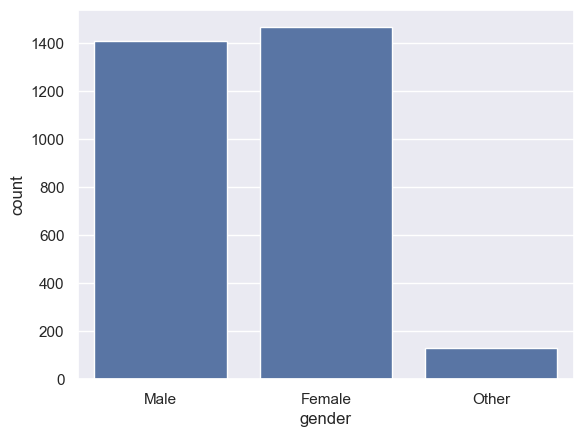

In [9]:
sns.countplot(x='gender',data=df)

In [10]:
df['gender'].value_counts(normalize=True)*100

gender
Female    48.833333
Male      46.900000
Other      4.266667
Name: proportion, dtype: float64

#### even distribution of customers between male and female, with female being marginally higher, others or not speciafied are mere 4%, suggesting gender alone is not a significant feature to predict annual_revenue.

###  City Tier

<Axes: xlabel='city_tier', ylabel='count'>

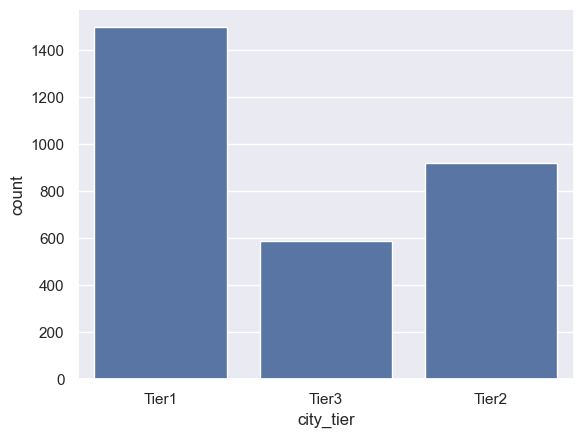

In [13]:
sns.countplot(x='city_tier',data=df)

In [14]:
df['city_tier'].value_counts(normalize=True)*100

city_tier
Tier1    49.9
Tier2    30.6
Tier3    19.5
Name: proportion, dtype: float64

#### tier 1 dominates being almost 50% of the total stores, followed by tier2 at 30% and then tier3 at 20%, Tier 1 cities dominate the total share of stores.

## Analysing Numerical columns
### Age

In [17]:
df['age'].describe()

count    3000.000000
mean       39.917333
std        12.078844
min         1.000000
25%        32.000000
50%        40.000000
75%        48.000000
max       120.000000
Name: age, dtype: float64

In [18]:
age=df['age'].unique()
age.sort()
age

array([  1,   3,   4,   5,   7,   8,   9,  10,  11,  12,  13,  14,  15,
        16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,  27,  28,
        29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,  40,  41,
        42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,  53,  54,
        55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,  66,  67,
        68,  69,  70,  71,  72,  73,  75,  76,  77,  78,  86,  87,  99,
       110, 120], dtype=int64)

<Axes: xlabel='age', ylabel='Count'>

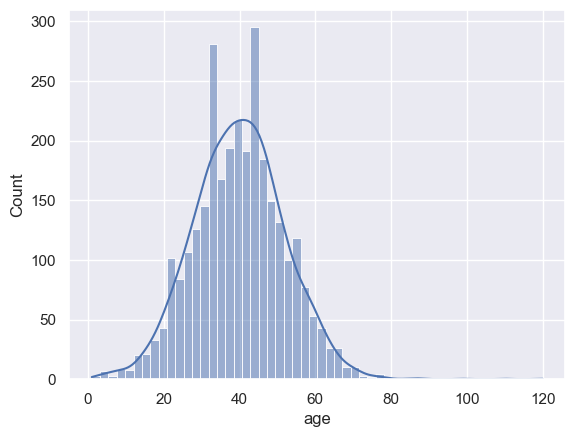

In [19]:
sns.histplot(x='age',data=df,kde=True)

In [20]:
df[df['age'] <=18]

,customer_id,age,gender,city_tier,income,spending_score,num_transactions,membership_years,preferred_category,discount_usage,credit_score,annual_revenue
13,14,17,Other,Tier2,46502.893723,55,9,1,Grocery,0.763945,685.0,15245.791934
37,38,16,Other,Tier1,18376.975817,9,19,17,Fashion,0.561710,736.0,7622.629174
49,50,18,Female,Tier2,10008.791963,67,17,0,Electronics,0.154614,555.0,3300.847214
74,75,8,Male,Tier2,49728.216132,5,14,4,Electronics,0.527582,672.0,15091.903903
79,80,16,Female,Tier2,34025.430025,58,25,19,Electronics,0.068368,684.0,15022.887247
...,...,...,...,...,...,...,...,...,...,...,...,...
2896,2897,14,Female,Tier3,16805.175076,24,21,2,Electronics,0.024592,562.0,6625.086847
2947,2948,4,Male,Tier3,14704.919627,5,21,17,Grocery,0.548625,640.0,8913.654424
2958,2959,5,Male,Tier1,NaN,35,16,16,Grocery,0.080184,489.0,9131.431210
2968,2969,18,Female,Tier1,9804.754874,87,13,5,Electronics,0.303311,590.0,4706.610504


In [21]:
df[df['age']>80]

,customer_id,age,gender,city_tier,income,spending_score,num_transactions,membership_years,preferred_category,discount_usage,credit_score,annual_revenue
47,48,110,Female,Tier1,95144.330016,75,15,8,Electronics,0.266038,552.0,41115.127050
209,210,86,Male,Tier3,29944.848884,83,23,15,Electronics,0.505651,689.0,13859.092341
1308,1309,99,Male,Tier1,NaN,98,22,18,Fashion,NaN,541.0,7909.027390
2804,2805,120,Male,Tier2,11847.912014,15,18,20,Electronics,0.183500,696.0,8336.060775
2895,2896,87,Male,Tier2,83807.000309,14,22,16,Grocery,0.255273,659.0,34333.417852


#### Suspicious ages appear like random input errors

In [22]:
(109/3000)*100

3.6333333333333337

#### 3.5% rows have extreme age counts which is too low compared to the dataset, replace these ages with the median age, which is detected as 40 above


In [106]:
df.loc[(df['age'] < 18) | (df['age'] > 80), 'age'] =40

In [108]:
df['age'].describe()

count    3000.000000
mean       40.604667
std        10.815577
min        18.000000
25%        33.000000
50%        40.000000
75%        48.000000
max        78.000000
Name: age, dtype: float64

<Axes: xlabel='age', ylabel='Count'>

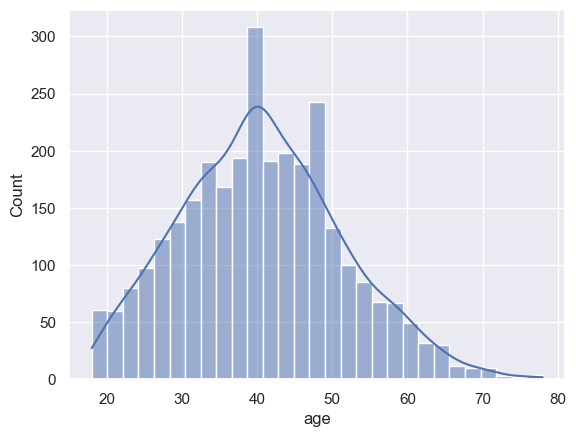

In [110]:
sns.histplot(x='age',data=df,kde=True)

#### age is normally distrbuted with a min of 18 and a max of 78

### spending_score      

In [28]:
df['spending_score'].describe()

count    3000.000000
mean       50.898667
std        29.230781
min         1.000000
25%        25.000000
50%        51.000000
75%        76.000000
max       100.000000
Name: spending_score, dtype: float64

In [29]:
df['spending_score'].unique()

array([ 63,  71,  47,  84,  81,   3,  46,  36,  26,  10,  34,  78,   8,
        55,  91,  57,  79,  86,  45,  50,  64,  95,   2,  62,  14,  74,
        94, 100,  15,  31,  29,  27,  85,   9,  20,  99,  58,  88,  49,
        16,  75,  67,  19,  89,  60,  11,  51,  80,  54,  17,  42,  24,
        48,  70,   7,  12,   5,  90,  97,  30,  87,  73,  22,  98,  96,
        28,  52,  93,  59,   6,  25,  76,  18,  68,  33,  83,  69,  39,
         4,  65,  40,  37,  77,  13,  44,  66,  41,  53,  32,  82,  92,
        23,  61,  35,  21,  38,  72,   1,  56,  43], dtype=int64)

<Axes: xlabel='spending_score', ylabel='Count'>

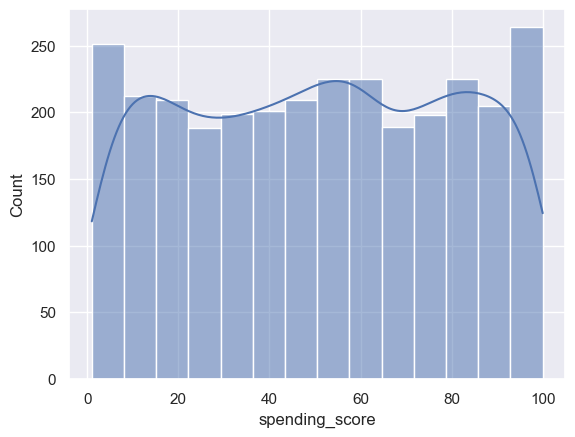

In [30]:
sns.histplot(x='spending_score',data=df,kde=True)


#### spending score is fairly distributed across the range

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         3000 non-null   int64  
 1   age                 3000 non-null   int64  
 2   gender              3000 non-null   object 
 3   city_tier           3000 non-null   object 
 4   income              2640 non-null   float64
 5   spending_score      3000 non-null   int64  
 6   num_transactions    3000 non-null   int64  
 7   membership_years    3000 non-null   int64  
 8   preferred_category  3000 non-null   object 
 9   discount_usage      2850 non-null   float64
 10  credit_score        2760 non-null   float64
 11  annual_revenue      3000 non-null   float64
dtypes: float64(4), int64(5), object(3)
memory usage: 281.4+ KB


### num_transactions

In [34]:
df['num_transactions'].describe()

count    3000.000000
mean       20.079667
std         4.538008
min         6.000000
25%        17.000000
50%        20.000000
75%        23.000000
max        37.000000
Name: num_transactions, dtype: float64

<Axes: xlabel='num_transactions', ylabel='Count'>

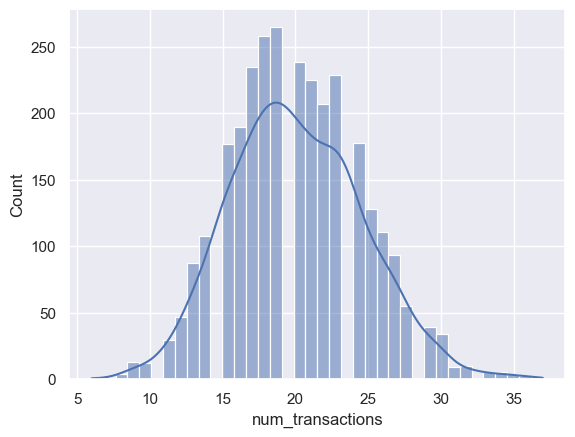

In [35]:
sns.histplot(data=df,x='num_transactions',kde=True)

#### num_transactions are normally distributed as well with most customers having 15-25 transactions

### membership_years

In [38]:
df['membership_years'].describe()

count    3000.000000
mean       10.155333
std         6.048311
min         0.000000
25%         5.000000
50%        10.000000
75%        15.000000
max        20.000000
Name: membership_years, dtype: float64

<Axes: xlabel='membership_years', ylabel='Count'>

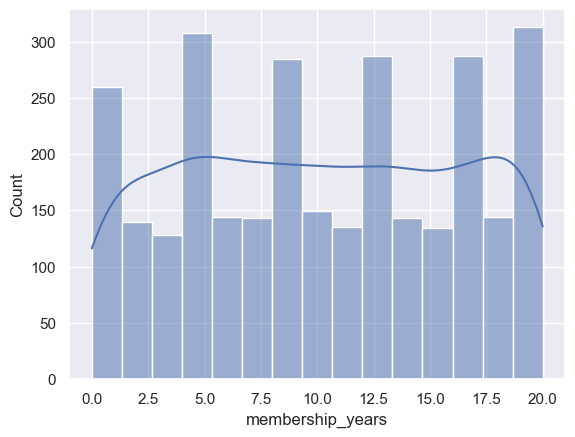

In [39]:
sns.histplot(x='membership_years',data=df,kde=True)

In [40]:
df['membership_years'].unique()

array([12,  9,  4, 10, 13, 19, 14,  2,  8,  7,  0,  1, 20, 16,  5, 17, 18,
        6,  3, 11, 15], dtype=int64)

In [41]:
df['membership_years'].value_counts(normalize=True)*100

membership_years
19    5.533333
4     5.133333
5     5.133333
17    5.066667
10    4.966667
8     4.933333
20    4.900000
6     4.800000
12    4.800000
18    4.800000
7     4.766667
14    4.766667
13    4.766667
2     4.666667
9     4.566667
11    4.500000
16    4.500000
15    4.466667
1     4.333333
0     4.333333
3     4.266667
Name: proportion, dtype: float64

#### membership_years are also fairly evenly distributed

### preferred_category

In [44]:
df['preferred_category'].unique()

array(['Electronics', 'Grocery', 'Fashion', 'Luxury'], dtype=object)

<Axes: xlabel='preferred_category', ylabel='count'>

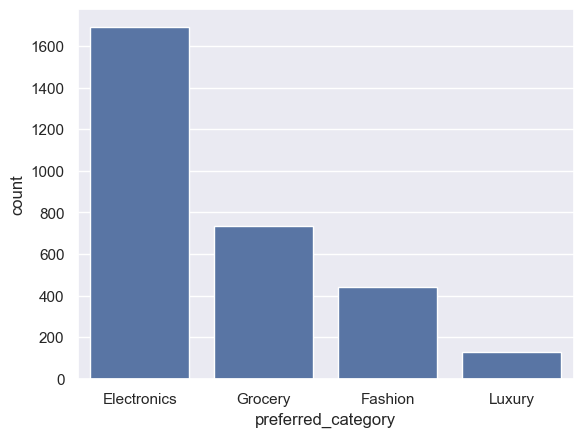

In [45]:
sns.countplot(x='preferred_category',data=df)

In [46]:
df['preferred_category'].value_counts(normalize=True)*100

preferred_category
Electronics    56.366667
Grocery        24.566667
Fashion        14.800000
Luxury          4.266667
Name: proportion, dtype: float64

#### Electronics totally dominate the market with 56% of the customers having it as the preferred category, followed by grocery at 24%, fashion at 14% and luxury items at just 4%, do the electronics bring out the max revenue will be checked later

### annual_revenue

In [49]:
df['annual_revenue'].describe()

count     3000.000000
mean     11154.248440
std       7140.796779
min       1430.448445
25%       6610.205546
50%       9251.267126
75%      13527.470365
max      82507.149549
Name: annual_revenue, dtype: float64

<Axes: xlabel='annual_revenue', ylabel='Count'>

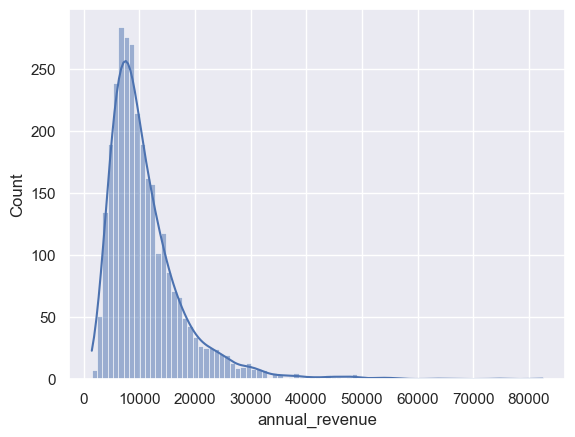

In [50]:
sns.histplot(x='annual_revenue',data=df,kde=True)

#### as expected it is a positive skew, with most customers spending upto 20000 but few customers way higher than most, the max revenue generated by a customer is 80k+

### Handling Missing Values

In [53]:
df.isnull().sum()

customer_id             0
age                     0
gender                  0
city_tier               0
income                360
spending_score          0
num_transactions        0
membership_years        0
preferred_category      0
discount_usage        150
credit_score          240
annual_revenue          0
dtype: int64

### Income

In [55]:
df.sample(20)

,customer_id,age,gender,city_tier,income,spending_score,num_transactions,membership_years,preferred_category,discount_usage,credit_score,annual_revenue
539,540,33,Male,Tier1,36889.701953,2,16,20,Electronics,0.131113,730.0,16368.208551
208,209,46,Male,Tier1,122900.148751,98,22,5,Electronics,0.247131,680.0,30250.914055
2498,2499,49,Other,Tier1,9988.887011,67,18,19,Electronics,0.321183,825.0,7970.389948
2082,2083,22,Female,Tier2,49245.065130,92,27,18,Grocery,0.200734,651.0,22462.672079
294,295,44,Male,Tier3,NaN,50,27,13,Fashion,0.282744,540.0,10615.676868
616,617,41,Female,Tier2,33421.645667,84,27,11,Electronics,0.457818,651.0,12905.216744
2076,2077,47,Male,Tier3,27129.920360,41,24,20,Grocery,0.552718,588.0,13415.862266
1137,1138,25,Female,Tier3,86402.538212,52,25,10,Grocery,NaN,611.0,29068.520254
2106,2107,29,Male,Tier3,5798.837679,34,22,12,Grocery,0.457894,644.0,4387.647729
1957,1958,77,Female,Tier2,NaN,59,15,1,Electronics,0.226259,625.0,9706.061129


#### city tier-wise findind records with missing income values

In [56]:
nan_income = df.groupby('city_tier')['income'].apply(lambda x: x.isna().sum()).reset_index()

<Axes: xlabel='city_tier', ylabel='income'>

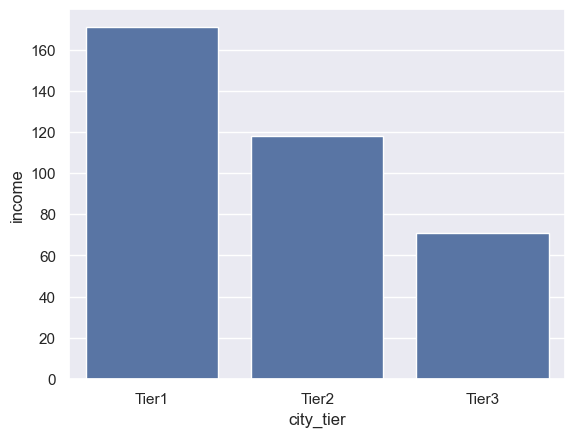

In [57]:
sns.barplot(data=nan_income, x='city_tier', y='income')


In [58]:
nan_income

,city_tier,income
0,Tier1,171
1,Tier2,118
2,Tier3,71


In [112]:
df['income'].describe()

count      2640.000000
mean      27659.869647
std       21555.733732
min        2386.721017
25%       13252.044884
50%       21656.955598
75%       34805.777471
max      200561.560631
Name: income, dtype: float64

#### replacing the missing value in income by city tier's income median respectively

In [60]:
df.groupby('city_tier')['income'].median()

city_tier
Tier1    21622.388885
Tier2    21841.373910
Tier3    21475.265977
Name: income, dtype: float64

In [61]:
df['income'].median()

21656.95559809436

<Axes: xlabel='income', ylabel='Count'>

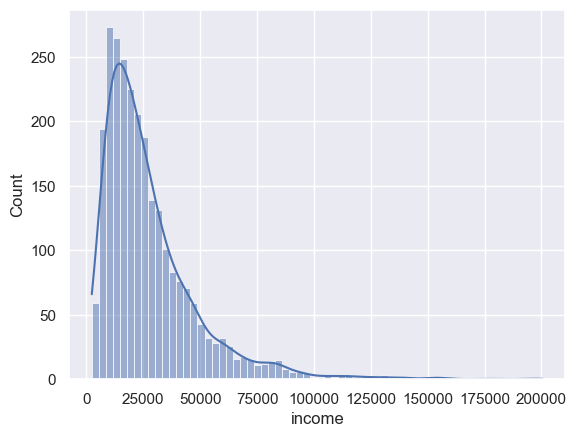

In [62]:
sns.histplot(x='income',data=df,kde=True)

#### median income across tiers is approximately equall, replacing missing values by income median

In [114]:
df['income']=df['income'].fillna(21656.95559809436)

In [116]:
df['income'].describe()

count      3000.000000
mean      26939.519961
std       20314.518655
min        2386.721017
25%       14247.704236
50%       21656.955598
75%       32272.797418
max      200561.560631
Name: income, dtype: float64

<Axes: xlabel='income', ylabel='Count'>

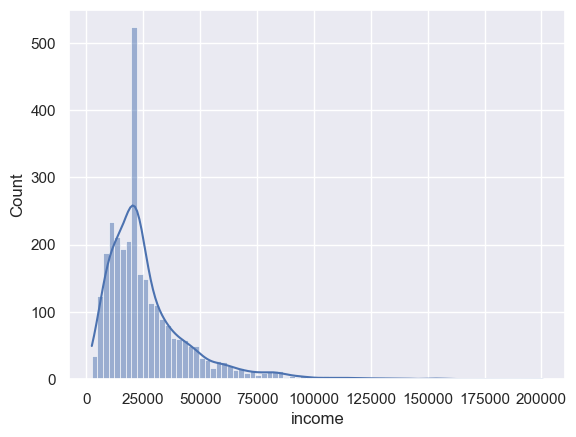

In [118]:
sns.histplot(x='income',data=df,kde=True)

#### Postive skew seen in the income as most people earn upto 35-40k, but a few customers have way higher income upto 2lacs

### discount_usage


In [122]:
df['discount_usage'].describe()

count    2850.000000
mean        0.285087
std         0.157572
min         0.003445
25%         0.159750
50%         0.267768
75%         0.390545
max         0.812171
Name: discount_usage, dtype: float64

<Axes: xlabel='discount_usage', ylabel='Count'>

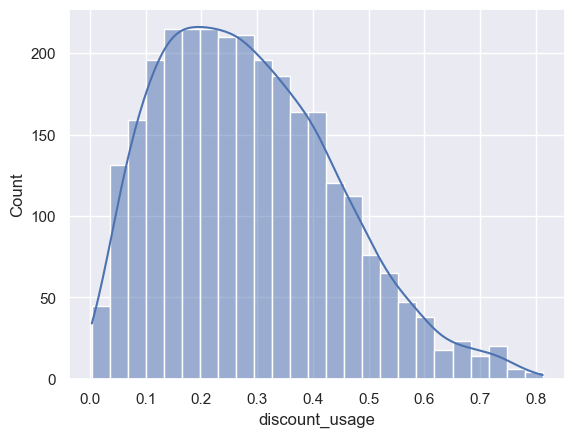

In [124]:
sns.histplot(x='discount_usage',data=df,kde=True)

#### slight positive skew detected, with most shop on low-moderate discounts 30%, whereas a few are dependent on really heavy discount rates upto 80%

#### only 150 values missing thus replacing them by the median

In [130]:
df['discount_usage'] = df['discount_usage'].fillna(df['discount_usage'].median())

In [132]:
df['discount_usage'].describe()

count    3000.000000
mean        0.284221
std         0.153628
min         0.003445
25%         0.166030
50%         0.267768
75%         0.382590
max         0.812171
Name: discount_usage, dtype: float64

<Axes: xlabel='discount_usage', ylabel='Count'>

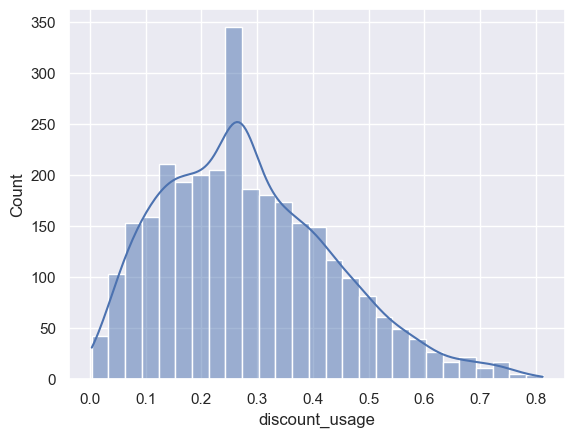

In [134]:
sns.histplot(x='discount_usage',data=df,kde=True)

### credit_score

In [137]:
df['credit_score'].describe()

count    2760.000000
mean      646.593116
std        79.487262
min        50.000000
25%       593.000000
50%       649.000000
75%       699.000000
max      1200.000000
Name: credit_score, dtype: float64

<Axes: xlabel='credit_score', ylabel='Count'>

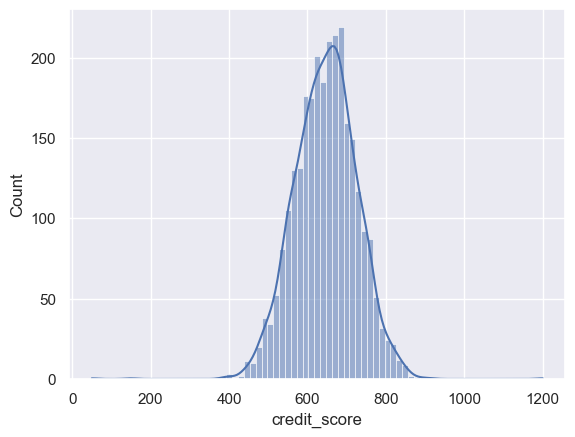

In [141]:
sns.histplot(x='credit_score',data=df,kde=True)

In [143]:
df.sample(3)

,customer_id,age,gender,city_tier,income,spending_score,num_transactions,membership_years,preferred_category,discount_usage,credit_score,annual_revenue
137,138,36,Male,Tier1,56169.715250,12,17,19,Electronics,0.219211,675.0,22460.481249
1922,1923,27,Male,Tier1,26325.524613,85,27,7,Electronics,0.130227,631.0,10007.668723
1531,1532,18,Female,Tier1,16794.109374,86,20,19,Fashion,0.166314,621.0,9439.041620


In [155]:
missing_credit=df[df['credit_score'].isna()]

In [171]:
missing_credit[['income','membership_years','discount_usage','annual_revenue']].sample(10)

,income,membership_years,discount_usage,annual_revenue
252,34774.833109,14,0.513899,14593.825486
1932,25918.503185,11,0.202307,12400.411233
1235,8148.325721,18,0.290184,6443.468339
303,20727.800411,2,0.249347,9416.527040
2133,130630.347337,8,0.469801,37880.681796
800,17015.483156,10,0.439376,8470.940221
1662,11506.321206,0,0.136908,4508.338490
538,118217.188783,7,0.301043,24265.418796
242,15221.557172,6,0.186816,5670.592470
2422,23137.409465,4,0.259596,7203.345374


#### Missing values in the credit_score variable were investigated to determine whether they followed any systematic pattern. An inspection of related features such as membership_years, income, annual_revenue, and discount_usage showed no consistent relationship with the missing entries. The missing values appear to be randomly distributed across the dataset, suggesting that the missingness is likely Missing Completely At Random (MCAR).

In [174]:
df['credit_score']=df['credit_score'].fillna(df['credit_score'].median())

In [176]:
df['credit_score'].isnull().sum()

0

<Axes: xlabel='credit_score', ylabel='Count'>

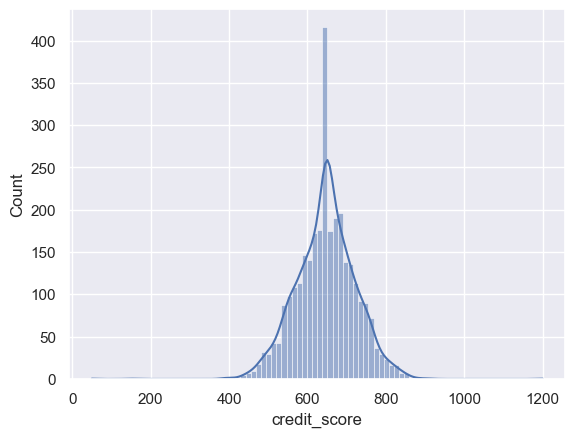

In [178]:
sns.histplot(x='credit_score',data=df,kde=True)

In [180]:
df['credit_score'].describe()

count    3000.000000
mean      646.785667
std        76.243195
min        50.000000
25%       598.750000
50%       649.000000
75%       693.250000
max      1200.000000
Name: credit_score, dtype: float64

#### credit score is normally distributed, most customers have good credit scores

In [183]:
df.isnull().sum()

customer_id           0
age                   0
gender                0
city_tier             0
income                0
spending_score        0
num_transactions      0
membership_years      0
preferred_category    0
discount_usage        0
credit_score          0
annual_revenue        0
dtype: int64

In [185]:
df.describe()

,customer_id,age,income,spending_score,num_transactions,membership_years,discount_usage,credit_score,annual_revenue
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1500.500000,40.604667,26939.519961,50.898667,20.079667,10.155333,0.284221,646.785667,11154.248440
std,866.169729,10.815577,20314.518655,29.230781,4.538008,6.048311,0.153628,76.243195,7140.796779
min,1.000000,18.000000,2386.721017,1.000000,6.000000,0.000000,0.003445,50.000000,1430.448445
25%,750.750000,33.000000,14247.704236,25.000000,17.000000,5.000000,0.166030,598.750000,6610.205546
50%,1500.500000,40.000000,21656.955598,51.000000,20.000000,10.000000,0.267768,649.000000,9251.267126
75%,2250.250000,48.000000,32272.797418,76.000000,23.000000,15.000000,0.382590,693.250000,13527.470365
max,3000.000000,78.000000,200561.560631,100.000000,37.000000,20.000000,0.812171,1200.000000,82507.149549


## BiVariate Analysis

In [188]:
df.columns

Index(['customer_id', 'age', 'gender', 'city_tier', 'income', 'spending_score',
       'num_transactions', 'membership_years', 'preferred_category',
       'discount_usage', 'credit_score', 'annual_revenue'],
      dtype='object')

### Age

<Axes: xlabel='age', ylabel='annual_revenue'>

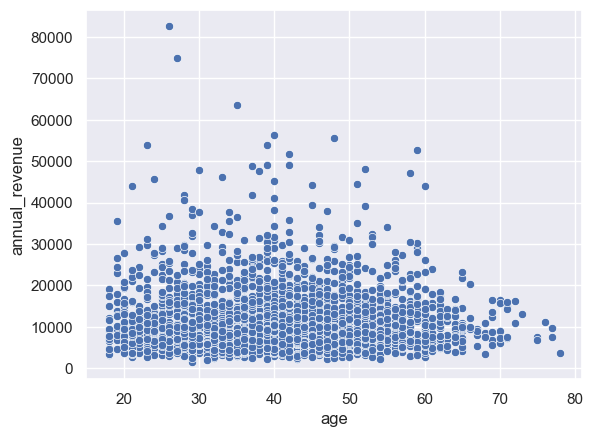

In [190]:
sns.scatterplot(x='age',y='annual_revenue',data=df)

#### age does not have a strong relationship with revenue, the band of revenue is pretty much constant throught all age groups

### Gender

<Axes: xlabel='gender', ylabel='annual_revenue'>

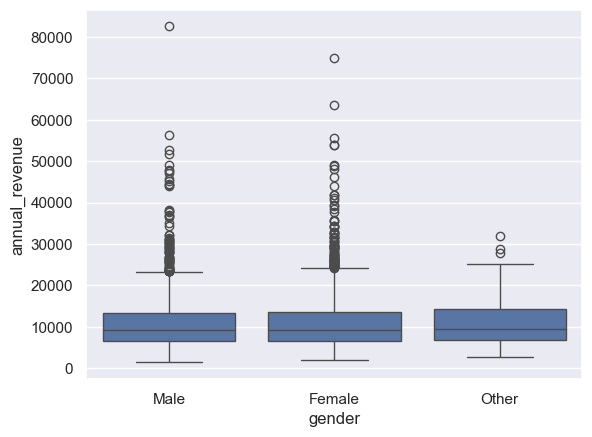

In [195]:
sns.boxplot(x='gender',y='annual_revenue',data=df)

In [199]:
df.groupby('gender')['annual_revenue'].agg(['mean','median','std','max','sum'])

,mean,median,std,max,sum
gender,,,,,
Female,11250.553898,9260.478200,7364.498978,74792.436987,1.648206e+07
Male,11045.015888,9240.848804,6990.273513,82507.149549,1.554034e+07
Other,11252.707075,9507.315844,6139.054290,32004.181541,1.440347e+06


#### mean and median are simliar across genders suggesting that gender alone is not a significant predictor in the dataset, total revenue generated by female is slightly higher but there are more fefmale customers in the datset as well

### city_tier

<Axes: xlabel='city_tier', ylabel='annual_revenue'>

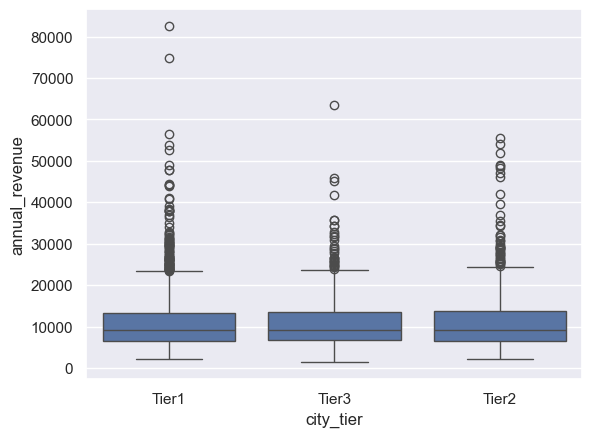

In [205]:
sns.boxplot(x='city_tier',y='annual_revenue',data=df)

In [207]:
df.groupby('city_tier')['annual_revenue'].agg(['mean','median','std','max','sum'])

,mean,median,std,max,sum
city_tier,,,,,
Tier1,11203.098890,9239.925790,7358.835343,82507.149549,1.677104e+07
Tier2,11067.649743,9273.746613,6973.083357,55626.956929,1.016010e+07
Tier3,11165.134730,9235.306207,6838.553297,63524.621889,6.531604e+06


#### mean and median are simliar across city tiers suggesting that city tiers alone is not a significant predictor in the dataset, total revenue generated by Tier1 is higher than the other 2 but there are more tier1 stores  in the datset as well

### income

<Axes: xlabel='income', ylabel='annual_revenue'>

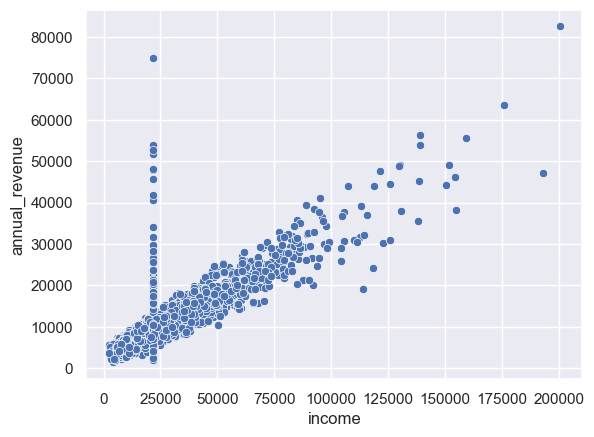

In [211]:
sns.scatterplot(x='income',y='annual_revenue',data=df)

#### strong positive correlation detected, suggesting income to be the most signoficant predictor for revenue

In [214]:
df.columns

Index(['customer_id', 'age', 'gender', 'city_tier', 'income', 'spending_score',
       'num_transactions', 'membership_years', 'preferred_category',
       'discount_usage', 'credit_score', 'annual_revenue'],
      dtype='object')

#### spending_score

<Axes: xlabel='spending_score', ylabel='annual_revenue'>

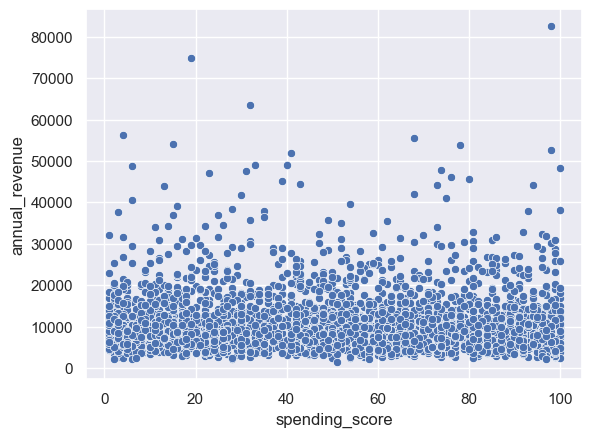

In [217]:
sns.scatterplot(x='spending_score',y='annual_revenue',data=df)

#### spending_score does not have a strong relationship with revenue, the band of revenue is pretty much constant throught all spending_scores.

### num_transactions

<Axes: xlabel='num_transactions', ylabel='annual_revenue'>

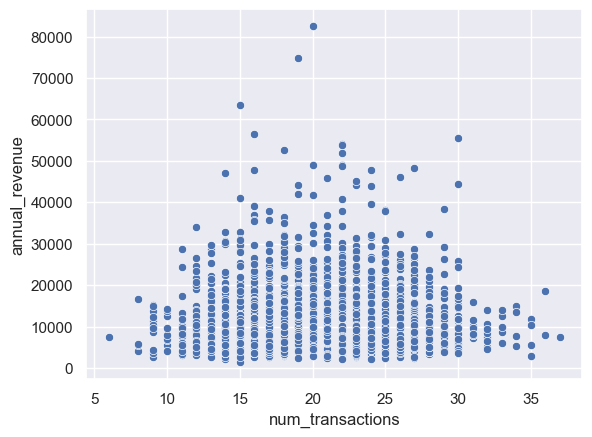

In [221]:
sns.scatterplot(x='num_transactions',y='annual_revenue',data=df)

#### There is no strong linear relationship between the two variables. Increasing the number of transactions does not consistently lead to higher annual revenue.

In [228]:
df.columns

Index(['customer_id', 'age', 'gender', 'city_tier', 'income', 'spending_score',
       'num_transactions', 'membership_years', 'preferred_category',
       'discount_usage', 'credit_score', 'annual_revenue'],
      dtype='object')

### membership_years

<Axes: xlabel='membership_years', ylabel='annual_revenue'>

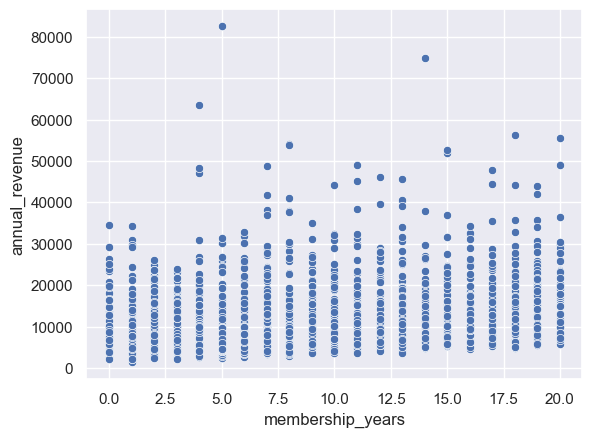

In [231]:
sns.scatterplot(x='membership_years',y='annual_revenue',data=df)

#### There is no strong linear relationship between the two variables. Increasing the number of membership_years does not show lead to higher annual revenue.

### preferred_category

<Axes: xlabel='preferred_category', ylabel='annual_revenue'>

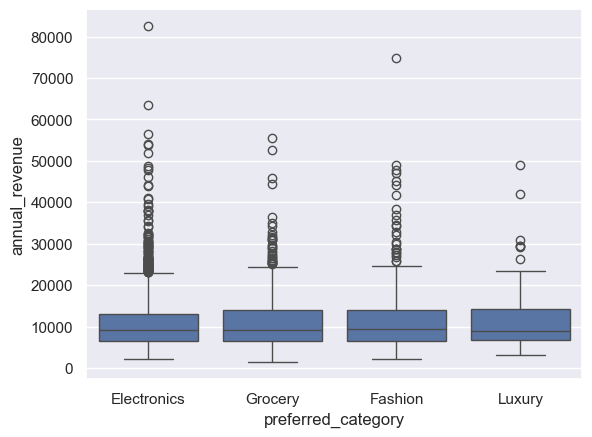

In [246]:
sns.boxplot(x='preferred_category',y='annual_revenue',data=df)

In [237]:
df.groupby('preferred_category')['annual_revenue'].agg(['mean','median','std','max','sum'])

,mean,median,std,max,sum
preferred_category,,,,,
Electronics,11031.323209,9224.001454,7077.782476,82507.149549,1.865397e+07
Fashion,11586.386924,9493.431421,7974.541235,74792.436987,5.144356e+06
Grocery,11164.335444,9307.109573,6716.996339,55626.956929,8.228115e+06
Luxury,11221.146533,9003.950208,7303.089678,49084.246017,1.436307e+06


#### total annual revenue of electronics outclasses all other categories, groceries come in next, followed by fashion and luxury items

### discount_usage

<Axes: xlabel='discount_usage', ylabel='annual_revenue'>

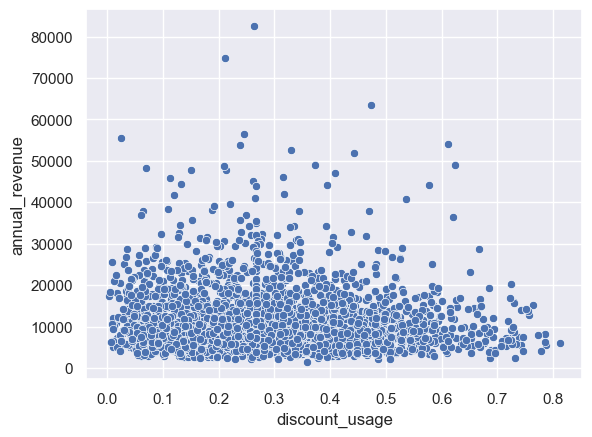

In [249]:
sns.scatterplot(x='discount_usage',y='annual_revenue',data=df)

#### discount usage has a weak influnce on annual revenue, higher discount usage or lower discount usage does not show any trend with annual revenue.

### credit_score

<Axes: xlabel='credit_score', ylabel='annual_revenue'>

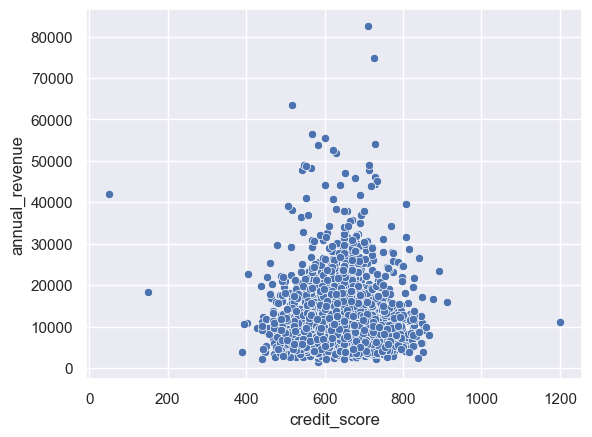

In [253]:
sns.scatterplot(x='credit_score',y='annual_revenue',data=df)

#### Low correlation detected. A customer's credit score is not a strong predictor of how much revenue they will generate, Having a perfect credit score doesn't necessarily mean the customer will spend the most. The biggest spenders are actually in the middle-to-high credit range, rather than at the absolute maximum.

### Retail Customer Revenue EDA — Summary of Insights

The exploratory analysis of the retail customer dataset reveals a customer base that is broadly balanced across demographic groups, while revenue generation appears to be driven more strongly by economic capacity than by demographic attributes.

Customer distribution across gender is nearly even between male and female customers, with female customers contributing only a marginally larger share, while the "Other / unspecified" category accounts for a very small proportion of the dataset (approximately 4%). Revenue statistics across gender groups show highly similar mean and median values, indicating that gender alone is not a strong determinant of annual revenue generation.

From a geographic perspective, Tier 1 cities dominate the dataset, representing nearly half of all customer records, followed by Tier 2 (approximately 30%) and Tier 3 (approximately 20%). Although Tier 1 contributes the highest total revenue, this is largely explained by its larger representation in the dataset. Similar mean and median revenue values across city tiers suggest that city tier alone is not a strong predictive feature for annual revenue.

The age variable follows a near-normal distribution, with customers ranging from 18 to 78 years old. Bivariate analysis shows that annual revenue remains widely dispersed across all age groups, with no visible upward or downward trend. This indicates that age does not meaningfully influence customer revenue in this dataset.

Behavioral variables such as spending_score, num_transactions, and membership_years also display broad and relatively even distributions. Spending score is fairly spread across its full range, yet shows no clear linear relationship with annual revenue, as customers across all spending score levels generate both low and high revenue. Similarly, the number of transactions—despite being normally concentrated around 15 to 25 purchases—does not consistently translate into higher revenue, suggesting that transaction frequency alone does not explain customer value. Membership duration follows the same pattern, with no evidence that longer customer tenure directly leads to greater annual revenue.

Product preference reveals a strong market concentration in Electronics, which accounts for 56% of customer preference, far exceeding Grocery (24%), Fashion (14%), and Luxury items (4%). Electronics also generates the highest total annual revenue by a significant margin, confirming its dominant role in the business. Grocery follows as the second strongest contributor, while Fashion and Luxury remain comparatively smaller segments.

Revenue itself exhibits a strong positive skew: most customers generate annual revenue below 20,000, while a smaller number of high-value customers contribute disproportionately larger amounts, with maximum revenue exceeding 80,000. A similar positive skew is present in income, where most customers earn within the 35,000–40,000 range, while a few high-income individuals extend up to 200,000. Among all features analyzed, income shows the strongest positive relationship with annual revenue, making it the most significant predictor in the dataset.

Discount usage is mildly right-skewed, with most customers using discounts in low-to-moderate proportions (around 30%), while a smaller segment relies heavily on discounts up to 80%. However, discount usage demonstrates only a weak influence on annual revenue, with no clear pattern suggesting that either higher or lower discount dependence leads to greater spending.

Credit score follows an approximately normal distribution, with most customers concentrated in the good credit range. Despite this financial stability pattern, correlation with annual revenue remains weak. High creditworthiness does not necessarily translate into higher customer value; in fact, the largest spenders are concentrated in the mid-to-high credit range rather than among customers with the absolute highest scores.

Overall, the analysis suggests that economic capacity (income) and product preference (especially Electronics) are the strongest revenue drivers, whereas demographic attributes, discount behavior, transaction count, membership duration, and credit score contribute relatively little as standalone predictors.

Strong Business Takeaways 📌

Income is the strongest predictor of annual revenue

Electronics is the dominant revenue-generating category

Demographic variables have limited predictive power

High transaction frequency does not guarantee high-value customers

Discount dependence does not strongly influence revenue

Revenue concentration is driven by a relatively small high-value customer segment

## MultiVariate Analysis

In [283]:
my_corr=df.corr(numeric_only=True,method='spearman')
my_corr

,customer_id,age,income,spending_score,num_transactions,membership_years,discount_usage,credit_score,annual_revenue
customer_id,1.000000,0.003639,-0.015707,-0.004172,0.017698,0.008715,-0.033161,-0.001709,-0.008652
age,0.003639,1.000000,-0.010764,0.042139,0.023306,0.004207,0.032185,-0.002908,-0.006332
income,-0.015707,-0.010764,1.000000,-0.018073,-0.004034,0.030190,-0.008071,0.007748,0.859684
spending_score,-0.004172,0.042139,-0.018073,1.000000,0.027465,0.014371,0.001056,0.012091,-0.009688
num_transactions,0.017698,0.023306,-0.004034,0.027465,1.000000,0.008599,-0.038170,0.005886,0.055828
membership_years,0.008715,0.004207,0.030190,0.014371,0.008599,1.000000,0.005825,0.020496,0.286719
discount_usage,-0.033161,0.032185,-0.008071,0.001056,-0.038170,0.005825,1.000000,-0.009326,-0.051592
credit_score,-0.001709,-0.002908,0.007748,0.012091,0.005886,0.020496,-0.009326,1.000000,0.015118
annual_revenue,-0.008652,-0.006332,0.859684,-0.009688,0.055828,0.286719,-0.051592,0.015118,1.000000


In [265]:
df.corr(numeric_only=True)['annual_revenue']

customer_id         0.005713
age                -0.024689
income              0.847597
spending_score     -0.007904
num_transactions    0.045452
membership_years    0.189445
discount_usage     -0.050850
credit_score       -0.004520
annual_revenue      1.000000
Name: annual_revenue, dtype: float64

In [269]:
df.corr(numeric_only=True,method='spearman')['annual_revenue']

customer_id        -0.008652
age                -0.006332
income              0.859684
spending_score     -0.009688
num_transactions    0.055828
membership_years    0.286719
discount_usage     -0.051592
credit_score        0.015118
annual_revenue      1.000000
Name: annual_revenue, dtype: float64

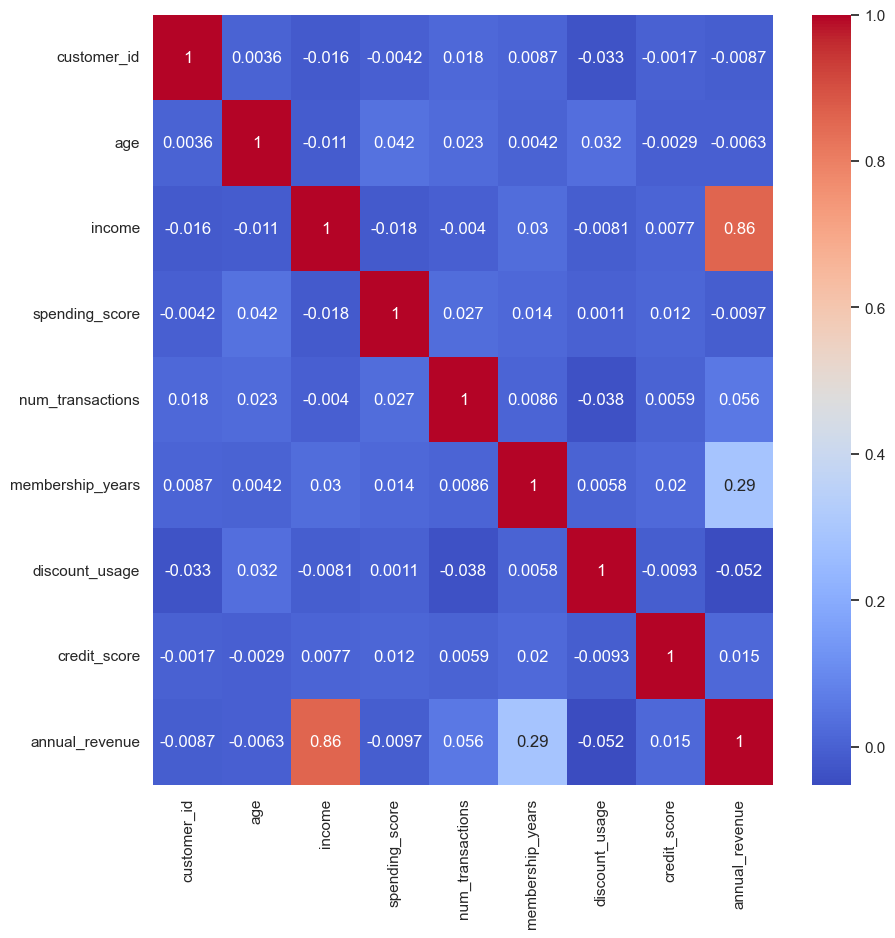

In [279]:
plt.figure(figsize=(10,10))
sns.heatmap(my_corr,annot=True,cmap='coolwarm')
plt.show()

### Gender × Region → Annual Revenue

In [290]:
df.groupby(['city_tier','gender'])['annual_revenue'].agg(['mean','median','std','max','sum'])

mean        median          std           max  \
city_tier gender                                                          
Tier1     Female  11082.261951   9053.542834  7275.515329  74792.436987   
          Male    11263.330943   9531.302289  7515.796529  82507.149549   
          Other   11908.834523  10686.486616  6495.612480  32004.181541   
Tier2     Female  11157.983651   9245.705276  7404.345271  55626.956929   
          Male    10958.606309   9287.015026  6551.799326  51802.554640   
          Other   11196.094136   9590.250493  6256.572848  28795.179636   
Tier3     Female  11817.911823   9828.416215  7518.521243  63524.621889   
          Male    10598.141529   8913.373436  6153.079847  45754.187512   
          Other    9922.182144   8947.848847  5089.361548  25027.111803   

                           sum  
city_tier gender                
Tier1     Female  7.968146e+06  
          Male    8.064545e+06  
          Other   7.383477e+05  
Tier2     Female  5.110357e+06  
          Male    4.635490e+06  
          Other   4.142555e+05  
Tier3     Female  3.403559e+06  
          Male    2.840302e+06  
          Other   2.877433e+05

In [329]:
Tier_revenue=df.groupby(['city_tier','gender'])['annual_revenue'].agg(['mean','median','std','max','sum'])

<Axes: xlabel='city_tier', ylabel='sum'>

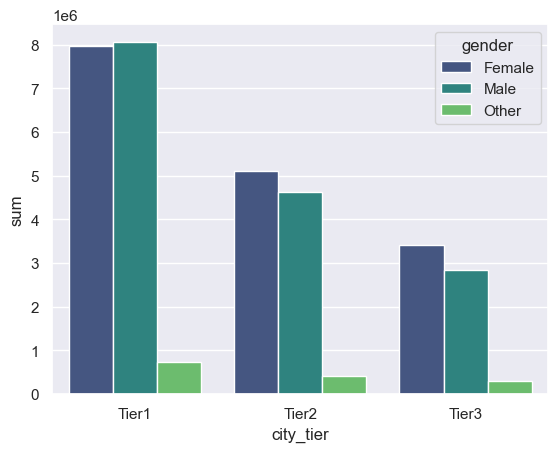

In [337]:
sns.barplot(y='sum',x='city_tier',hue='gender',palette='viridis',data=Tier_revenue)

#### Women spend more than Men in both Tier 2 and Tier 3 cities. If you were designing a marketing strategy, you would target Men in the major metros (Tier 1) and focus more on Women in the smaller cities (Tier 2 & 3). Surprisingly others seem to be the highest spenders in tier 1 cities.

### Preferred category * Gender -> Revenue

In [313]:
df.groupby(['preferred_category','gender'])['annual_revenue'].agg(['mean','median','std','max','sum'])

mean        median          std  \
preferred_category gender                                            
Electronics        Female  11366.164846   9384.486191  7493.608483   
                   Male    10693.057992   9159.156217  6704.510805   
                   Other   10973.219733   8578.632285  6101.361611   
Fashion            Female  11643.951080   9428.444459  8599.764299   
                   Male    11354.739513   9543.965095  7322.666888   
                   Other   13460.590587  10974.162135  7984.332550   
Grocery            Female  10765.580190   8918.721109  6314.578004   
                   Male    11678.776151   9586.889806  7254.886880   
                   Other   10406.714746   9424.381196  4903.769738   
Luxury             Female  11299.170211   9448.097894  6998.943149   
                   Male    11092.648955   8008.504966  7826.450639   
                   Other   12169.425502  11426.607048  2024.582613   

                                    max           sum  
preferred_category gender                              
Electronics        Female  63524.621889  9.308889e+06  
                   Male    82507.149549  8.533060e+06  
                   Other   27861.529681  8.120183e+05  
Fashion            Female  74792.436987  2.445230e+06  
                   Male    47787.931222  2.429914e+06  
                   Other   32004.181541  2.692118e+05  
Grocery            Female  55626.956929  4.004796e+06  
                   Male    52645.073859  3.900711e+06  
                   Other   24476.914539  3.226082e+05  
Luxury             Female  41938.449140  7.231469e+05  
                   Male    49084.246017  6.766516e+05  
                   Other   14460.496240  3.650828e+04

In [327]:
category_revenue=df.groupby(['preferred_category','gender'])['annual_revenue'].agg(['mean','median','std','max','sum'])


<Axes: xlabel='preferred_category', ylabel='sum'>

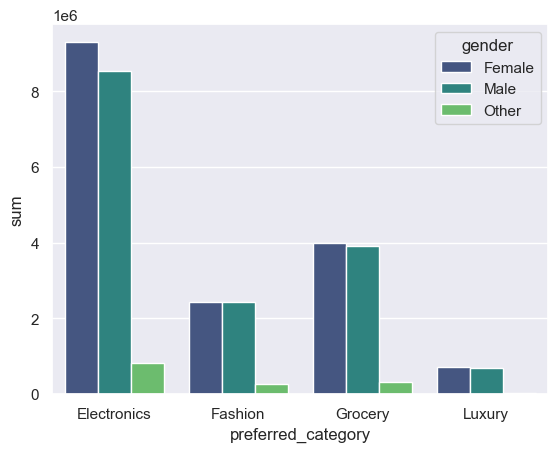

In [325]:
sns.barplot(x='preferred_category',y='sum',hue='gender',data=category_revenue,palette='viridis')

#### To maximize growth, data suggests the following paths:
Men have a higher average transaction value. This often indicates "stock-up" shopping (buying a lot at once) versus more frequent, smaller trips.
Focus on Women in Electronics. They are your core "bread and butter."
Target the Other gender category for Fashion and Luxury—they spend the most per visit.

In [341]:
df.columns

Index(['customer_id', 'age', 'gender', 'city_tier', 'income', 'spending_score',
       'num_transactions', 'membership_years', 'preferred_category',
       'discount_usage', 'credit_score', 'annual_revenue'],
      dtype='object')

### preferred category * city tier -> revenue

In [350]:
category_tier=df.groupby(['city_tier','preferred_category'])['annual_revenue'].agg(['sum','mean','median','std'])
category_tier

sum          mean       median  \
city_tier preferred_category                                            
Tier1     Electronics         9.482643e+06  11195.564247  9344.678498   
          Fashion             2.540052e+06  12038.159162  9702.593369   
          Grocery             4.104186e+06  10886.435774  9122.429580   
          Luxury              6.441583e+05  10389.649225  8934.140932   
Tier2     Electronics         5.604964e+06  10737.478220  9217.671025   
          Fashion             1.496108e+06  10841.361068  9273.746613   
          Grocery             2.547291e+06  11684.823195  9619.104203   
          Luxury              5.117395e+05  12793.488738  9110.686536   
Tier3     Electronics         3.566361e+06  11075.655277  9053.329413   
          Fashion             1.108196e+06  11665.225094  9500.200330   
          Grocery             1.576637e+06  11103.080839  9405.984057   
          Luxury              2.804090e+05  10784.959798  9555.008745   

                                      std  
city_tier preferred_category               
Tier1     Electronics         7379.384340  
          Fashion             8865.318959  
          Grocery             6618.639636  
          Luxury              5342.300655  
Tier2     Electronics         6757.383204  
          Fashion             6291.256040  
          Grocery             7206.284147  
          Luxury              9923.511099  
Tier3     Electronics         6774.698580  
          Fashion             8071.765838  
          Grocery             6175.933319  
          Luxury              6466.341588

<Axes: xlabel='sum', ylabel='city_tier'>

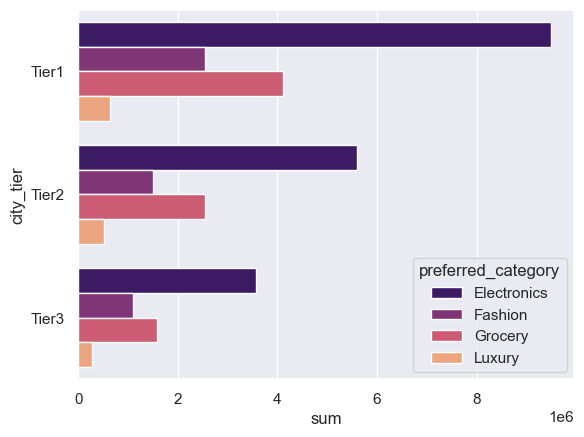

In [354]:
sns.barplot(x='sum', y='city_tier',hue='preferred_category',palette='magma',data=category_tier)

Based on the comprehensive breakdown of city tiers and product categories, it is clear that Tier 1 cities serve as your primary revenue engine, largely fueled by a massive 9.48 million in Electronics sales. However, while Electronics dominates the total volume, Fashion actually commands a higher average transaction value in these major hubs, with a mean spend of 12,038. In contrast, Tier 2 cities present a unique high-value opportunity in the Luxury sector; despite lower total sums, the Tier 2 luxury shopper spend peaks at an average of 12,793, which is the highest individual transaction mean across the entire dataset. Tier 3 cities follow a "quality over quantity" trend in Fashion, maintaining a strong average spend that outperforms Electronics in per-purchase value. Across all regions, Grocery remains the most stable and predictable category, showing consistent spending patterns regardless of city size. Ultimately, your strategy should lean into the high-volume Electronics market in Tier 1 while pivoting toward premium, targeted marketing for Luxury and Fashion in Tiers 2 and 3 to capture those higher-margin individual sales.

### Income × Spending Score × Revenue

<Axes: xlabel='income', ylabel='annual_revenue'>

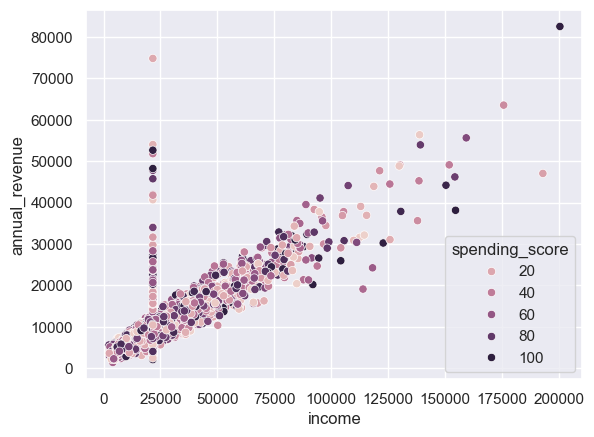

In [361]:
sns.scatterplot(x='income',y='annual_revenue',hue='spending_score',data=df)

#### The Darker Dots (Spending Score 80-100): Notice that the darkest points tend to sit at the "top" of the diagonal cluster. This means that if two people have the same income, the one with the higher spending score will almost always generate more revenue.

### Credit Score × Income × Revenue

<Axes: xlabel='income', ylabel='annual_revenue'>

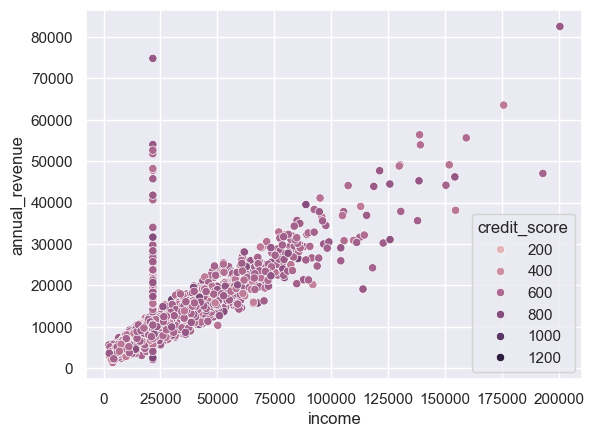

In [367]:
sns.scatterplot(x='income',y='annual_revenue',hue='credit_score',data=df)

#### annual_revenue is dominated by mid-level credit score

### Annual revenue + Discount usage + preferred category

<Axes: xlabel='discount_usage', ylabel='annual_revenue'>

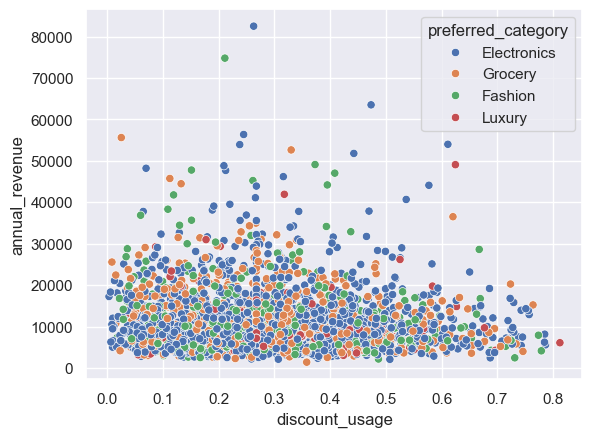

In [374]:
sns.scatterplot(y='annual_revenue',x='discount_usage',hue='preferred_category',data=df)

Even at the far right of the graph ($0.6$ to $0.8$ discount usage), Electronics remains the most frequent category. This suggests that your electronics customers are highly sensitive to "deals" and will keep buying as long as there is a price cut.

In [377]:
df.columns

Index(['customer_id', 'age', 'gender', 'city_tier', 'income', 'spending_score',
       'num_transactions', 'membership_years', 'preferred_category',
       'discount_usage', 'credit_score', 'annual_revenue'],
      dtype='object')

### revenue + income + num_transaction

<Axes: xlabel='income', ylabel='annual_revenue'>

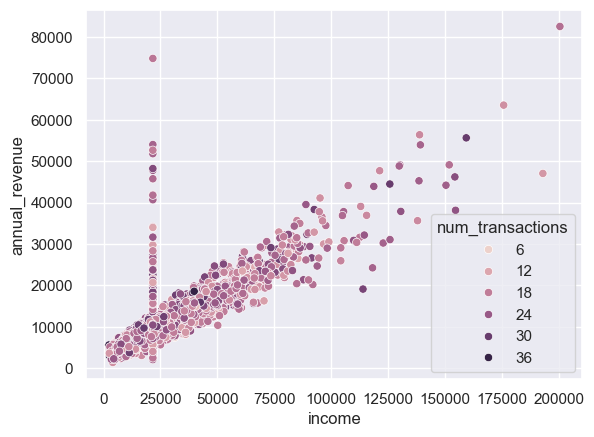

In [379]:
sns.scatterplot(y='annual_revenue',x='income',hue='num_transactions',data=df)

#### high number of transaction are scattered around the graph, not always the highest, suggesting num of transactions is not a key driver in annual revenue

### Multivariate Analysis Summary — Retail Customer Revenue EDA

The multivariate analysis reveals that annual revenue is driven by the interaction of demographic, geographic, behavioral, and category-based customer factors rather than any single variable alone.

A strong regional-gender spending pattern emerges across city tiers. Women consistently generate higher revenue than men in Tier 2 and Tier 3 cities, indicating stronger purchasing influence in developing urban markets, while men remain relatively stronger contributors in Tier 1 metropolitan regions, suggesting that marketing strategies should differ by geography: metro campaigns can target male purchasing behavior, whereas smaller-city growth strategies should prioritize female consumer segments. Interestingly, the "Other" gender category records the highest spending levels in Tier 1 cities, indicating a niche but high-value premium segment that may respond well to highly personalized campaigns.

Category-level interactions further strengthen segmentation insight. Electronics clearly dominates total revenue, particularly in Tier 1 cities, contributing nearly 9.48 million in sales, making it the primary revenue engine of the business. However, while Electronics leads in volume, Fashion demonstrates higher average transaction values in Tier 1 cities, showing that customers spend more per purchase even if total volume is lower. In Tier 2 cities, Luxury emerges as the highest-value category by transaction average, reaching approximately 12,793, the highest mean spend observed across the dataset, suggesting that premium category marketing can unlock strong margins in emerging urban markets. Tier 3 cities follow a quality-over-quantity pattern in Fashion, where average spending remains high despite lower total sales volume. By contrast, Grocery remains the most stable category across all city tiers, showing highly predictable and consistent spending behavior independent of region.

Behavioral analysis adds another important layer. Men exhibit higher average transaction values, which often suggests stock-up purchasing behavior—fewer but larger purchases—whereas other segments may contribute through more frequent moderate purchases. Women show particularly strong performance in Electronics, making them a critical volume-driving segment, while Fashion and Luxury purchases by the Other gender segment produce the highest spend per visit, indicating premium purchase concentration in niche groups.

Discount behavior reveals category-specific revenue sensitivity. Even at high discount usage levels, Electronics remains the most dominant purchasing category, suggesting that electronics customers are highly responsive to deal-based incentives and continue purchasing when pricing advantages are offered. This implies that discount-led campaigns can be highly effective for sustaining electronics volume, but pricing strategy should remain category-sensitive to protect margins elsewhere.

Customer financial behavior shows that higher spending scores strongly align with higher annual revenue, especially when income levels are comparable. Within similar income groups, customers with stronger spending scores consistently generate more revenue, making spending score a critical behavioral predictor. In contrast, annual revenue appears concentrated among mid-range credit score customers, indicating that extremely high creditworthiness does not necessarily translate into proportionally higher spending.

A notable finding is that number of transactions alone is not a dominant revenue driver. High transaction counts are scattered across revenue levels, showing that more purchases do not automatically produce higher annual revenue; instead, transaction quality and basket size matter more than frequency.



### Final Conclusion — Retail Customer Revenue EDA

The analysis shows that annual revenue is shaped by a combination of customer spending behavior, product preference, and geographic segmentation rather than basic demographics alone. While gender distribution remains nearly balanced and does not independently drive revenue, its interaction with city tier and product category reveals clear business patterns: women contribute more strongly in Tier 2 and Tier 3 cities, whereas Tier 1 revenue remains heavily driven by large-volume metropolitan spending.

At the category level, Electronics emerges as the dominant revenue generator, especially in Tier 1 cities, making it the core business driver, while Fashion and Luxury produce higher per-transaction value in specific segments, particularly in Tier 2 and Tier 3 markets, indicating strong premium-selling opportunities outside metro regions. Discount usage continues to sustain Electronics demand, showing high price sensitivity in that category, whereas Grocery remains the most stable and predictable segment across all regions.

Behavioral variables prove to be the strongest drivers of revenue. Customers with higher spending scores consistently generate greater annual revenue even within similar income groups, while average transaction value contributes more strongly than transaction frequency, showing that larger basket size matters more than the number of purchases. Revenue concentration around mid-range credit score customers further suggests that financial profile influences spending, but not as strongly as purchase behavior.

Overall, the data suggests that revenue growth should focus on high-value customer behavior, category-specific targeting, and region-based segmentation rather than broad demographic assumptions.

Most Important Features Influencing Annual Revenue 🎯

The strongest features influencing annual_revenue are:

Income

Spending Score

Average Transaction Value

Preferred Category

City Tier

Discount Usage

Credit Score

Gender (mainly when combined with city tier/category)

Lower influence:

Number of Transactions

Standalone Gender Distribution
